In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
BASE_DIR = Path("/content/drive/MyDrive/rostat")

MONTHLY_DIR = BASE_DIR / "monthly_forecast"
MONTHLY_DIR.mkdir(parents=True, exist_ok=True)

monthly_data = pd.read_csv(
    MONTHLY_DIR / "monthly_price_index_dataset.csv",
    parse_dates=["month_end"]
)

monthly_data = monthly_data.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

monthly_data["year"] = monthly_data["month_end"].dt.year
monthly_data["month"] = monthly_data["month_end"].dt.month

# На всякий случай исключаем 2026, если он есть и неполный
monthly_data = monthly_data[monthly_data["year"] <= 2025].copy()

display(monthly_data.head())

,product_group_code,product_group_name,month_end,mean_price,median_price,n_products,n_observations,is_imputed,year,month,price_index
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,64.656250,65.110,8.0,24.0,False,2016,1,100.000000
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-02-29,65.140750,65.300,8.0,40.0,False,2016,2,100.291814
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,65.685000,65.710,8.0,32.0,False,2016,3,100.921517
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-04-30,66.366563,66.160,8.0,32.0,False,2016,4,101.612656
4,G01,"Хлеб, крупы, мука и макаронные изделия",2016-05-31,67.327750,66.135,8.0,40.0,False,2016,5,101.574259


In [3]:
print("Период:", monthly_data["month_end"].min(), "—", monthly_data["month_end"].max())
print("Категорий:", monthly_data["product_group_code"].nunique())

display(
    monthly_data
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_months=("month_end", "nunique"),
        start_date=("month_end", "min"),
        end_date=("month_end", "max"),
        imputed_months=("is_imputed", "sum")
    )
)

Период: 2016-01-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 9


,product_group_code,product_group_name,n_months,start_date,end_date,imputed_months
0,G01,"Хлеб, крупы, мука и макаронные изделия",120,2016-01-31,2025-12-31,12
1,G02,Молочная продукция и яйца,120,2016-01-31,2025-12-31,12
2,G03,"Мясо, птица, рыба и колбасные изделия",120,2016-01-31,2025-12-31,12
3,G04,"Овощи, фрукты и картофель",120,2016-01-31,2025-12-31,12
4,G05,"Бакалея, масло, сахар, чай, соль",120,2016-01-31,2025-12-31,12
5,G07,"Товары для дома, гигиены и бытовая химия",120,2016-01-31,2025-12-31,12
6,G10,Топливо и транспортные товары,120,2016-01-31,2025-12-31,12
7,G11,Услуги,120,2016-01-31,2025-12-31,12
8,G99,Прочее,120,2016-01-31,2025-12-31,12


In [4]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [5]:
sarima_2025_configs = [
    {
        "model": "SARIMA no AR/MA, seasonal diff only",
        "component_test": "только сезонное дифференцирование",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA + nonseasonal MA",
        "component_test": "добавлена MA-компонента",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA + nonseasonal AR",
        "component_test": "добавлена AR-компонента",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA + seasonal MA",
        "component_test": "добавлена сезонная MA-компонента",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA MA + seasonal MA",
        "component_test": "MA + сезонная MA",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA AR + seasonal MA",
        "component_test": "AR + сезонная MA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA ARMA + seasonal MA",
        "component_test": "ARMA + сезонная MA",
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA MA + seasonal AR",
        "component_test": "MA + сезонная AR",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 0, 12)
    }
]

In [6]:
def run_full_2025_seasonal_naive(category_df, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["year"] < 2025].copy()
    valid_df = df[df["year"] == 2025].copy()

    if len(valid_df) != 12:
        raise ValueError("В validation за 2025 год должно быть 12 месяцев")

    if len(train_df) < 24:
        raise ValueError("Слишком мало train-данных")

    assert train_df["month_end"].max() < pd.Timestamp("2025-01-01"), (
        "Ошибка: 2025 год попал в train"
    )

    lookup = train_df.set_index(["month"])[y_col]

    # Прогноз каждого месяца 2025 = значение того же месяца 2024
    previous_year = train_df[train_df["year"] == 2024].copy()

    if previous_year["month"].nunique() != 12:
        raise ValueError("Нет полного 2024 года для Seasonal Naive")

    yhat = []

    for _, row in valid_df.iterrows():
        month_value = previous_year.loc[
            previous_year["month"] == row["month"],
            y_col
        ]

        if len(month_value) == 0:
            raise ValueError(f"Нет значения за месяц {row['month']} в 2024 году")

        yhat.append(float(month_value.iloc[0]))

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["component_test"] = "значение того же месяца прошлого года"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "component_test": "значение того же месяца прошлого года",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_months": len(train_df),
        "valid_months": len(valid_df),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [7]:
def run_full_2025_sarima(category_df, config, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["year"] < 2025].copy()
    valid_df = df[df["year"] == 2025].copy()

    if len(valid_df) != 12:
        raise ValueError("В validation за 2025 год должно быть 12 месяцев")

    if len(train_df) < 36:
        raise ValueError("Слишком мало train-данных для SARIMA")

    assert train_df["month_end"].max() < pd.Timestamp("2025-01-01"), (
        "Ошибка: 2025 год попал в train"
    )

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    model = SARIMAX(
        y_train,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=12
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = np.array(yhat)
    pred["model"] = config["model"]
    pred["model_type"] = "SARIMA"
    pred["component_test"] = config["component_test"]

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": config["model"],
        "model_type": "SARIMA",
        "component_test": config["component_test"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_months": len(train_df),
        "valid_months": len(valid_df),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [8]:
full_2025_metrics = []
full_2025_predictions = []
full_2025_models = {}

for group_code, category_df in monthly_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("month_end").copy()

    # Baseline
    try:
        pred, metrics = run_full_2025_seasonal_naive(
            category_df=category_df
        )

        full_2025_predictions.append(pred)
        full_2025_metrics.append(metrics)

        print(
            f"Seasonal Naive | "
            f"MAPE={metrics['MAPE']:.3f}, "
            f"sMAPE={metrics['sMAPE']:.3f}"
        )

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    # SARIMA configurations
    for config in sarima_2025_configs:
        try:
            result, pred, metrics = run_full_2025_sarima(
                category_df=category_df,
                config=config
            )

            full_2025_predictions.append(pred)
            full_2025_metrics.append(metrics)

            model_key = f"{group_code}_{config['model']}"
            full_2025_models[model_key] = result

            print(
                f"{config['model']} | "
                f"MAPE={metrics['MAPE']:.3f}, "
                f"sMAPE={metrics['sMAPE']:.3f}"
            )

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

full_2025_metrics_df = pd.DataFrame(full_2025_metrics)
full_2025_predictions_df = pd.concat(full_2025_predictions, ignore_index=True)

display(full_2025_metrics_df.head())

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=7.225, sMAPE=7.511
SARIMA no AR/MA, seasonal diff only | MAPE=4.527, sMAPE=4.646
SARIMA + nonseasonal MA | MAPE=4.272, sMAPE=4.380
SARIMA + nonseasonal AR | MAPE=2.746, sMAPE=2.792
SARIMA + seasonal MA | MAPE=2.103, sMAPE=2.130
SARIMA MA + seasonal MA | MAPE=1.915, sMAPE=1.938
SARIMA AR + seasonal MA | MAPE=1.103, sMAPE=1.111
SARIMA ARMA + seasonal MA | MAPE=1.128, sMAPE=1.137
SARIMA MA + seasonal AR | MAPE=9.191, sMAPE=9.708
Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=9.152, sMAPE=9.632
SARIMA no AR/MA, seasonal diff only | MAPE=2.424, sMAPE=2.420
SARIMA + nonseasonal MA | MAPE=2.580, sMAPE=2.583
SARIMA + nonseasonal AR | MAPE=3.510, sMAPE=3.564
SARIMA + seasonal MA | MAPE=1.490, sMAPE=1.475
SARIMA MA + seasonal MA | MAPE=1.289, sMAPE=1.268
SARIMA AR + seasonal MA | MAPE=2.290, sMAPE=2.241
SARIMA ARMA + seasonal MA | MAPE=1.488, sMAPE=1.459
SARIMA MA + seasonal AR | MAPE=2.462, sMAPE=2.4

,MAE,RMSE,MAPE,sMAPE,model,model_type,component_test,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_months,valid_months,AIC,BIC
0,11.582962,11.903465,7.225230,7.510591,Seasonal Naive,Seasonal Naive,значение того же месяца прошлого года,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,108,12,NaN,NaN
1,7.274715,7.774538,4.526865,4.646486,"SARIMA no AR/MA, seasonal diff only",SARIMA,только сезонное дифференцирование,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,108,12,-411.959337,-409.416042
2,6.867998,7.395345,4.272128,4.380181,SARIMA + nonseasonal MA,SARIMA,добавлена MA-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,108,12,-447.460375,-442.395176
3,4.415885,4.865035,2.745535,2.791928,SARIMA + nonseasonal AR,SARIMA,добавлена AR-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,108,12,-477.734368,-472.647779
4,3.382390,3.689531,2.103168,2.129513,SARIMA + seasonal MA,SARIMA,добавлена сезонная MA-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,108,12,-401.339817,-396.526378


In [9]:
leak_check = full_2025_metrics_df.copy()

leak_check["train_end"] = pd.to_datetime(leak_check["train_end"])
leak_check["valid_start"] = pd.to_datetime(leak_check["valid_start"])

leak_check["train_uses_2025"] = leak_check["train_end"] >= pd.Timestamp("2025-01-01")
leak_check["validation_is_2025"] = leak_check["valid_start"] >= pd.Timestamp("2025-01-01")

display(
    leak_check[
        [
            "model",
            "product_group_code",
            "product_group_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "train_uses_2025",
            "validation_is_2025"
        ]
    ].sort_values(["product_group_code", "model"])
)

print("Есть ли обучение на 2025 году?")
print(leak_check["train_uses_2025"].any())

,model,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_uses_2025,validation_is_2025
3,SARIMA + nonseasonal AR,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
2,SARIMA + nonseasonal MA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
4,SARIMA + seasonal MA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
6,SARIMA AR + seasonal MA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
7,SARIMA ARMA + seasonal MA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
...,...,...,...,...,...,...,...,...,...
79,SARIMA ARMA + seasonal MA,G99,Прочее,2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
80,SARIMA MA + seasonal AR,G99,Прочее,2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
77,SARIMA MA + seasonal MA,G99,Прочее,2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True
73,"SARIMA no AR/MA, seasonal diff only",G99,Прочее,2016-01-31,2024-12-31,2025-01-31,2025-12-31,False,True


Есть ли обучение на 2025 году?
False


In [10]:
full_2025_model_summary = (
    full_2025_metrics_df
    .groupby(["model_type", "model", "component_test"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_categories=("product_group_code", "nunique")
    )
    .sort_values("mean_MAPE")
)

display(full_2025_model_summary.round(3))

,model_type,model,component_test,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
4,SARIMA,SARIMA ARMA + seasonal MA,ARMA + сезонная MA,7.281,8.852,4.101,3.892,5.135,1.128,17.277,9
6,SARIMA,SARIMA MA + seasonal MA,MA + сезонная MA,7.511,9.049,4.222,4.021,5.067,1.220,17.206,9
2,SARIMA,SARIMA + seasonal MA,добавлена сезонная MA-компонента,7.591,9.079,4.262,4.068,4.999,1.036,17.062,9
3,SARIMA,SARIMA AR + seasonal MA,AR + сезонная MA,7.678,9.310,4.354,4.101,5.509,1.103,18.572,9
0,SARIMA,SARIMA + nonseasonal AR,добавлена AR-компонента,8.547,10.177,4.948,4.455,7.918,0.931,25.873,9
7,SARIMA,"SARIMA no AR/MA, seasonal diff only",только сезонное дифференцирование,8.934,10.533,5.078,4.673,7.375,0.850,24.281,9
1,SARIMA,SARIMA + nonseasonal MA,добавлена MA-компонента,9.009,10.592,5.148,4.717,7.481,0.956,24.736,9
5,SARIMA,SARIMA MA + seasonal AR,MA + сезонная AR,12.175,14.036,6.827,6.456,8.219,0.548,27.177,9
8,Seasonal Naive,Seasonal Naive,значение того же месяца прошлого года,18.546,19.826,9.554,10.156,5.213,1.086,19.979,9


In [11]:
best_full_2025_by_category = (
    full_2025_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_full_2025_display = best_full_2025_by_category.copy()

for col in ["MAE", "RMSE", "MAPE", "sMAPE", "AIC", "BIC"]:
    if col in best_full_2025_display.columns:
        best_full_2025_display[col] = best_full_2025_display[col].round(3)

display(
    best_full_2025_display[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "component_test",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ]
)

,product_group_code,product_group_name,model,component_test,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,G01,"Хлеб, крупы, мука и макаронные изделия",SARIMA AR + seasonal MA,AR + сезонная MA,1.776,2.133,1.103,1.111,2016-01-31,2024-12-31,2025-01-31,2025-12-31
1,G02,Молочная продукция и яйца,SARIMA MA + seasonal MA,MA + сезонная MA,2.474,4.123,1.289,1.268,2016-01-31,2024-12-31,2025-01-31,2025-12-31
2,G03,"Мясо, птица, рыба и колбасные изделия",SARIMA MA + seasonal AR,MA + сезонная AR,0.951,1.345,0.548,0.545,2016-01-31,2024-12-31,2025-01-31,2025-12-31
3,G04,"Овощи, фрукты и картофель",SARIMA + seasonal MA,добавлена сезонная MA-компонента,28.637,35.127,17.062,14.954,2016-01-31,2024-12-31,2025-01-31,2025-12-31
4,G05,"Бакалея, масло, сахар, чай, соль",SARIMA AR + seasonal MA,AR + сезонная MA,4.137,4.565,1.992,2.017,2016-01-31,2024-12-31,2025-01-31,2025-12-31
5,G07,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,значение того же месяца прошлого года,1.759,2.220,1.086,1.095,2016-01-31,2024-12-31,2025-01-31,2025-12-31
6,G10,Топливо и транспортные товары,"SARIMA no AR/MA, seasonal diff only",только сезонное дифференцирование,1.561,2.313,0.850,0.857,2016-01-31,2024-12-31,2025-01-31,2025-12-31
7,G11,Услуги,"SARIMA no AR/MA, seasonal diff only",только сезонное дифференцирование,7.996,8.316,4.147,4.243,2016-01-31,2024-12-31,2025-01-31,2025-12-31
8,G99,Прочее,SARIMA + nonseasonal MA,добавлена MA-компонента,2.625,3.703,1.362,1.380,2016-01-31,2024-12-31,2025-01-31,2025-12-31


In [12]:
best_keys = best_full_2025_by_category[
    [
        "product_group_code",
        "model"
    ]
].copy()

best_full_2025_predictions = full_2025_predictions_df.merge(
    best_keys,
    on=["product_group_code", "model"],
    how="inner"
)

best_full_2025_predictions = best_full_2025_predictions.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

display(best_full_2025_predictions.head(20))

,month_end,year,month,product_group_code,product_group_name,price_index,is_imputed,y,yhat,model,model_type,component_test
0,2025-01-31,2025,1,G01,"Хлеб, крупы, мука и макаронные изделия",154.584549,False,154.584549,152.365672,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
1,2025-02-28,2025,2,G01,"Хлеб, крупы, мука и макаронные изделия",154.761173,False,154.761173,153.614002,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
2,2025-03-31,2025,3,G01,"Хлеб, крупы, мука и макаронные изделия",156.512057,False,156.512057,154.858648,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
3,2025-04-30,2025,4,G01,"Хлеб, крупы, мука и макаронные изделия",157.587160,False,157.587160,157.732893,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
4,2025-05-31,2025,5,G01,"Хлеб, крупы, мука и макаронные изделия",158.332053,False,158.332053,158.612878,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
5,2025-06-30,2025,6,G01,"Хлеб, крупы, мука и макаронные изделия",159.345723,False,159.345723,158.991566,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
6,2025-07-31,2025,7,G01,"Хлеб, крупы, мука и макаронные изделия",160.344033,False,160.344033,159.242138,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
7,2025-08-31,2025,8,G01,"Хлеб, крупы, мука и макаронные изделия",161.196437,False,161.196437,159.452442,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
8,2025-09-30,2025,9,G01,"Хлеб, крупы, мука и макаронные изделия",161.680233,False,161.680233,159.360669,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA
9,2025-10-31,2025,10,G01,"Хлеб, крупы, мука и макаронные изделия",163.254492,False,163.254492,159.892493,SARIMA AR + seasonal MA,SARIMA,AR + сезонная MA


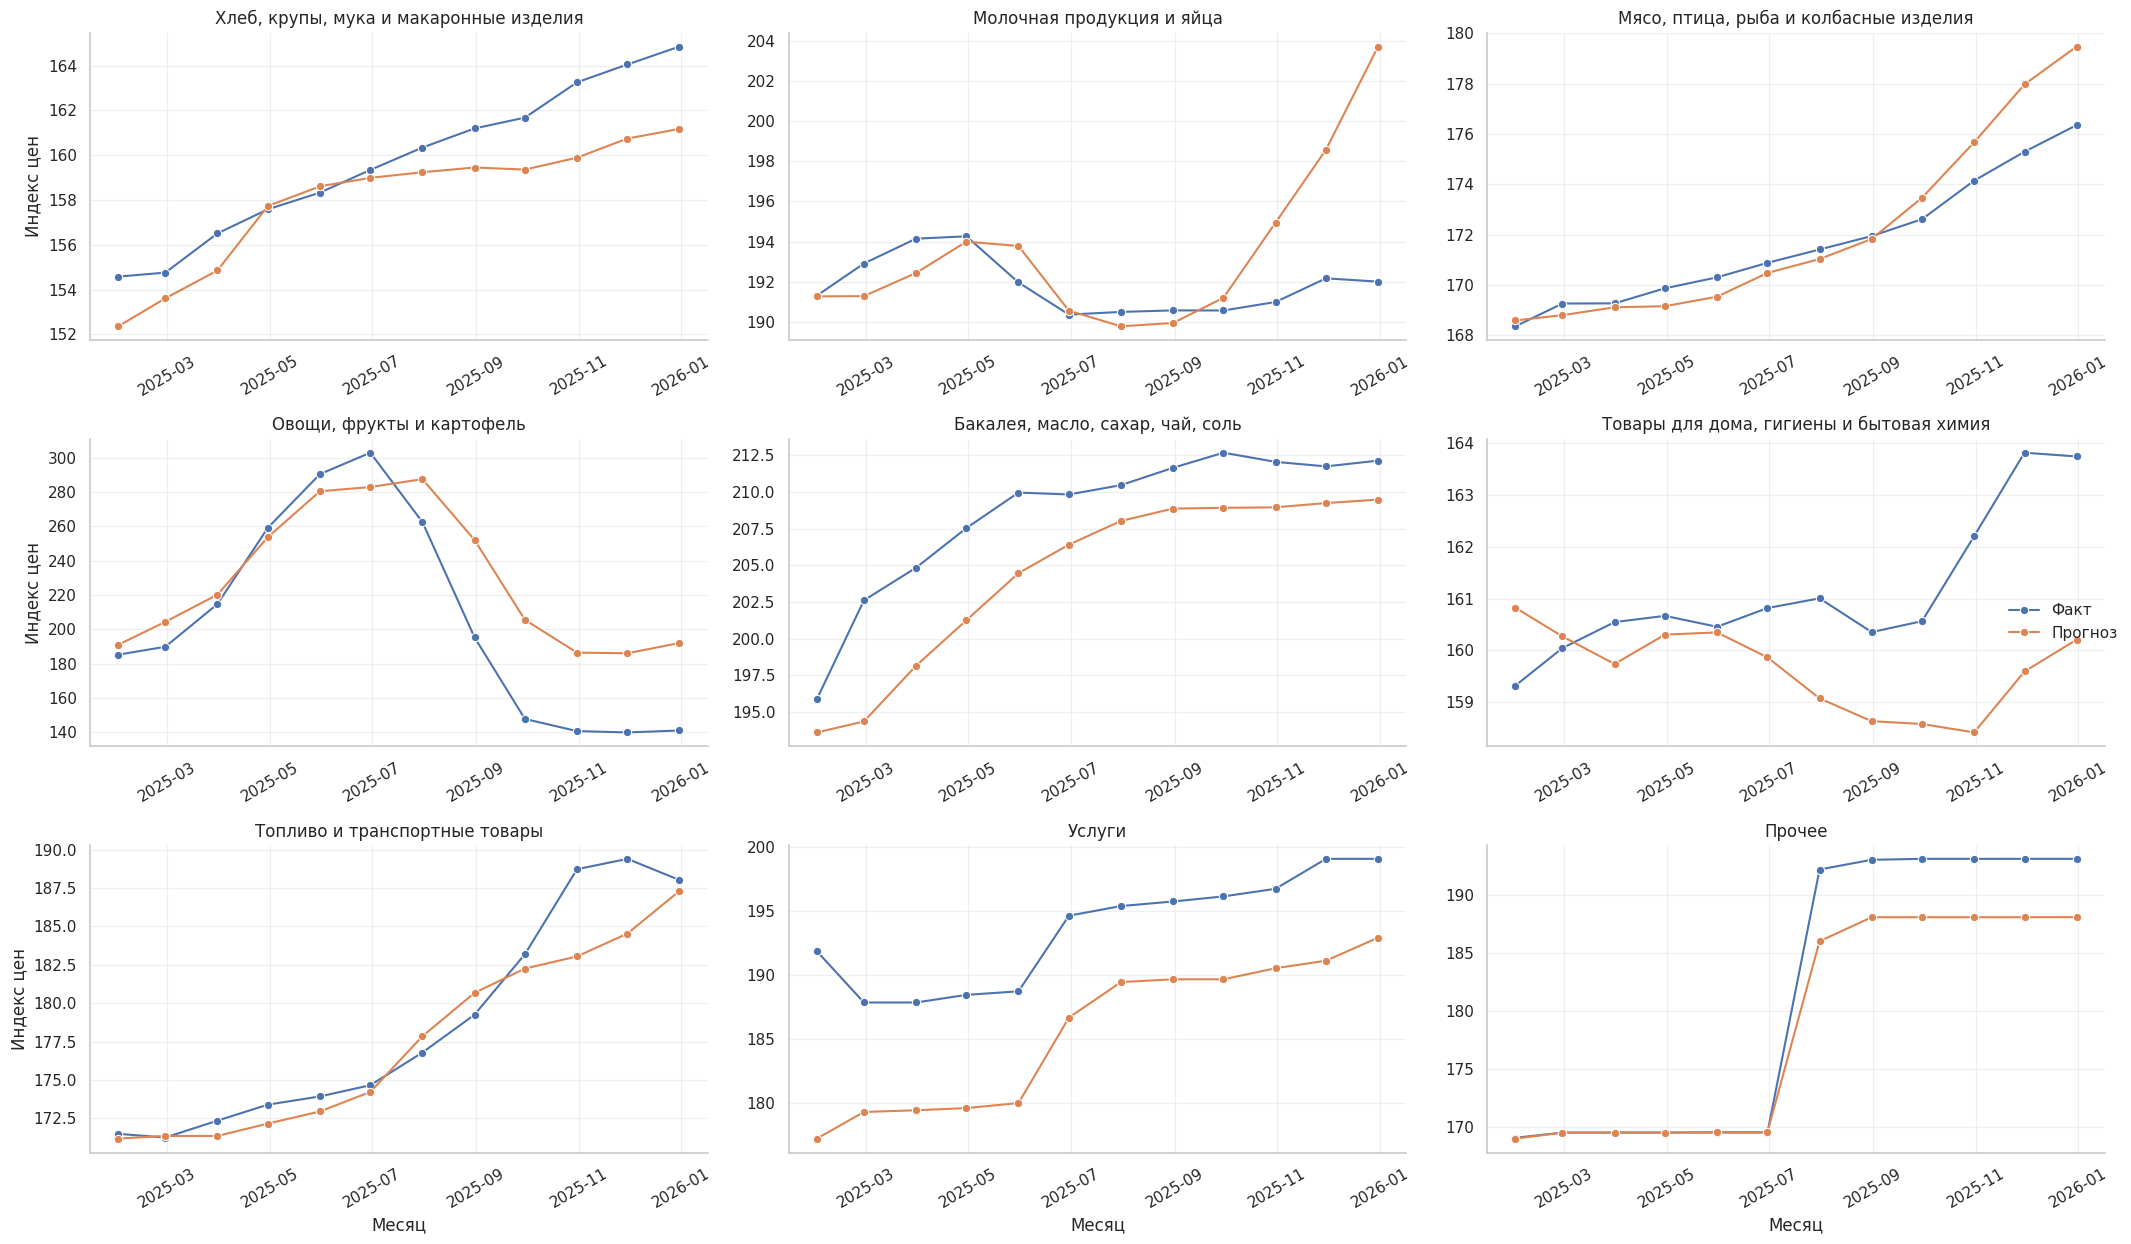

In [13]:
plot_full_2025 = pd.concat(
    [
        best_full_2025_predictions[
            [
                "month_end",
                "product_group_name",
                "y"
            ]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_full_2025_predictions[
            [
                "month_end",
                "product_group_name",
                "yhat"
            ]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_full_2025,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

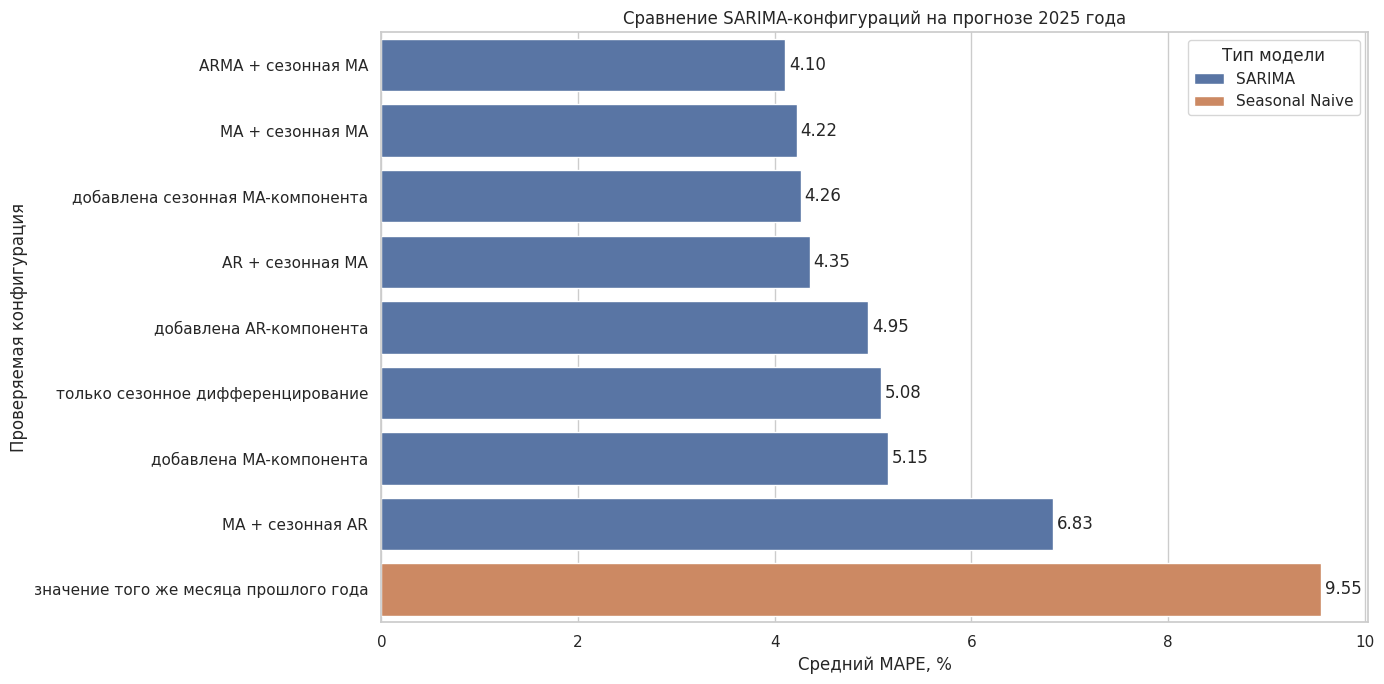

In [14]:
plt.figure(figsize=(14, 7))

plot_summary = full_2025_model_summary.sort_values("mean_MAPE")

ax = sns.barplot(
    data=plot_summary,
    x="mean_MAPE",
    y="component_test",
    hue="model_type",
    dodge=False
)

plt.title("Сравнение SARIMA-конфигураций на прогнозе 2025 года")
plt.xlabel("Средний MAPE, %")
plt.ylabel("Проверяемая конфигурация")
plt.legend(title="Тип модели")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [15]:
category_model_pivot = (
    full_2025_metrics_df
    .pivot_table(
        index="product_group_name",
        columns="model",
        values="MAPE",
        aggfunc="mean"
    )
)

display(category_model_pivot.round(3))

model,SARIMA + nonseasonal AR,SARIMA + nonseasonal MA,SARIMA + seasonal MA,SARIMA AR + seasonal MA,SARIMA ARMA + seasonal MA,SARIMA MA + seasonal AR,SARIMA MA + seasonal MA,"SARIMA no AR/MA, seasonal diff only",Seasonal Naive
product_group_name,,,,,,,,,
"Бакалея, масло, сахар, чай, соль",2.094,4.706,2.853,1.992,2.152,5.784,2.847,5.195,10.026
Молочная продукция и яйца,3.510,2.580,1.490,2.290,1.488,2.462,1.289,2.424,9.152
"Мясо, птица, рыба и колбасные изделия",0.931,1.247,1.036,1.588,1.546,0.548,1.220,1.096,5.060
"Овощи, фрукты и картофель",25.873,24.736,17.062,18.572,17.277,27.177,17.206,24.281,19.979
Прочее,1.362,1.362,4.210,4.201,4.202,5.222,4.201,1.362,11.264
"Товары для дома, гигиены и бытовая химия",2.304,2.238,2.534,2.513,2.420,2.123,2.430,1.823,1.086
Топливо и транспортные товары,1.469,0.956,1.625,1.516,1.430,0.913,1.496,0.850,9.817
Услуги,4.248,4.238,5.449,5.415,5.265,8.023,5.394,4.147,12.379
"Хлеб, крупы, мука и макаронные изделия",2.746,4.272,2.103,1.103,1.128,9.191,1.915,4.527,7.225


In [16]:
full_2025_metrics_df.to_csv(
    MONTHLY_DIR / "full_2025_sarima_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

full_2025_predictions_df.to_csv(
    MONTHLY_DIR / "full_2025_sarima_predictions_all_models.csv",
    index=False,
    encoding="utf-8-sig"
)

full_2025_model_summary.to_csv(
    MONTHLY_DIR / "full_2025_sarima_model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

best_full_2025_by_category.to_csv(
    MONTHLY_DIR / "full_2025_sarima_best_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

best_full_2025_predictions.to_csv(
    MONTHLY_DIR / "full_2025_sarima_best_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", MONTHLY_DIR)

Файлы сохранены в: /content/drive/MyDrive/rostat/monthly_forecast
